<a href="https://colab.research.google.com/github/techasit239/Final-Project---DADS6003/blob/main/M_L_FINAL_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import nltk

# โหลด tokenizer ของ NLTK
nltk.download('punkt')
nltk.download('punkt_tab')   # เพิ่มตัวนี้
nltk.download('averaged_perceptron_tagger')  # สำหรับ pos_tag ถ้าใช้

print("✅ NLTK resources loaded successfully!")

✅ NLTK resources loaded successfully!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


# Part 0 : INSTALL & IMPORT

In [50]:
# ==========================================================
# PART 0 : INSTALL & IMPORT
# ==========================================================
!pip install -q pandas numpy nltk textstat scikit-learn xgboost catboost matplotlib seaborn
!pip install interpret
!pip install optuna



import re
from statistics import pstdev
from typing import List, Tuple, Dict
from pathlib import Path

import numpy as np
import pandas as pd

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.tag import pos_tag

from textstat import textstat

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from interpret.glassbox import ExplainableBoostingClassifier


# NLTK resources
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger', quiet=True)
# บางเวอร์ชันต้องใช้ averaged_perceptron_tagger_eng
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)


# ==========================================================
# GLOBAL CONSTANTS (ใช้ร่วมในทุกส่วน)
# ==========================================================
POLITENESS = ["please", "thank", "appreciate", "thanks",
              "appreciated", "appreciates", "appreciation", "kindly"]
AGGRESSIVE = ["must", "now", "immediately", "demand", "require"]
URGENCY    = ["urgent", "asap", "immediately", "soon"]
CONDITIONAL = ["if", "unless", "provided", "should", "whenever"]
PERSONAL_TAGS = ["[recipient’s name]", "[recipient's name]",
                 "[Your Name]", "[Your name]"]

WORD_RE = re.compile(r"[a-zA-Z]+(?:'[a-zA-Z]+)?")

FUNCTION_WORDS = {
    'the', 'is', 'at', 'which', 'on', 'and', 'or', 'but', 'because', 'a', 'an'
}
PREPOSITIONS = {
    'in', 'on', 'at', 'by', 'with', 'from', 'to', 'of', 'for', 'about'
}
PRONOUN_TAGS = {'PRP', 'PRP$', 'WP', 'WP$'}
LINKING_WORDS = {'but', 'and', 'or', 'because', 'while', 'as', 'though', 'although'}

TARGET_PUNC = ['.', ',', ':', '-', '"', '(', ')', '/', '\\']

LINGUISTIC_COLUMNS = [
    'Word_Count', 'Character_Count', 'Average_Word_Length', 'Sentence_Count', 'Average_Sentence_Length',
    'Unique_Word_Count', 'Lexical_Diversity', 'Email_Count', 'Uppercase_Word_Count', 'Uppercase_Word_Count_Ratio',
    'Complex_Words_Count', 'Average_Syllables_per_Word',
    'Comma_Count', 'Semicolon_Count', 'Colon_Count', 'Exclamation_Count',
    'Quotation_Count', 'Dash_Count',
    'Sentence_Complexity_Ratio', 'Clause_Density', 'Pronoun_Density',
    'Preposition_Density', 'Function_Word_Density'
]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 2.8 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# Part 1 : FEATURE FUNCTIONS

In [43]:
# ==========================================================
# PART 1 : FEATURE FUNCTIONS
# ==========================================================

# ---------- 1. Loaders ----------
def _validate_cols(df: pd.DataFrame):
    required = {"Subject", "Body", "Label"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"คอลัมน์หายไป: {missing} (ต้องมี {required})")

def _sanitize_cols(df: pd.DataFrame):
    df["Subject"] = df["Subject"].astype(str).fillna("")
    df["Body"]    = df["Body"].astype(str).fillna("")

def load_email_excel(path: str) -> pd.DataFrame:
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"ไม่พบไฟล์: {p.resolve()}")
    df = pd.read_excel(p, engine="openpyxl")
    _validate_cols(df)
    _sanitize_cols(df)
    return df

def load_email_csv(path: str, encoding: str = "utf-8") -> pd.DataFrame:
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"ไม่พบไฟล์: {p.resolve()}")
    df = pd.read_csv(p, encoding=encoding)
    _validate_cols(df)
    _sanitize_cols(df)
    return df


# ---------- 2. Utilities ----------
def strip_urls_emails(text: str) -> str:
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)     # URL
    text = re.sub(r"\S+@\S+\.\S+", " ", text)              # Email
    return text

def tokenize_words(text: str) -> List[str]:
    text = text if isinstance(text, str) else ""
    text = strip_urls_emails(text)
    return [m.group(0).lower() for m in WORD_RE.finditer(text)]

def make_ngrams(tokens: List[str], n: int) -> List[Tuple[str, ...]]:
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def count_markers(tokens: List[str], vocab: List[str]) -> int:
    vocab_set = set(w.lower() for w in vocab)
    return sum(1 for t in tokens if t in vocab_set)

def count_phrase_occurrences(text: str, phrases: List[str]) -> int:
    lowered = (text or "").lower()
    return sum(len(re.findall(re.escape(p.lower()), lowered)) for p in phrases)


# ---------- 3. Extra 12 email-specific features ----------
def simple_tokenize(text: str):
    """
    tokenize แบบง่าย: คืน (words_lower, words_original)
    """
    if pd.isna(text):
        text = ""
    text = str(text)
    words_original = [m.group(0) for m in WORD_RE.finditer(text)]
    words_lower = [w.lower() for w in words_original]
    return words_lower, words_original

def extract_email_features(text: str) -> Dict[str, float]:
    """
    12 ฟีเจอร์เพิ่มเติมที่โฟกัส pattern ใน email
    """
    words, words_original = simple_tokenize(text)

    pronouns = ['i', 'you', 'he', 'she', 'it', 'we', 'they',
                'me', 'him', 'her', 'us', 'them']
    num_pronouns = sum(1 for w in words if w in pronouns)

    first_person_pronouns = ['i', 'we', 'me', 'us', 'my', 'our', 'mine', 'ours']
    first_person_pronoun_count = sum(1 for w in words if w in first_person_pronouns)

    second_person_pronouns = ['you', 'your', 'yours']
    second_person_pronoun_count = sum(1 for w in words if w in second_person_pronouns)

    imperative_verbs = ['click', 'verify', 'submit', 'download',
                        'update', 'open', 'enable', 'call', 'contact']
    imperative_verbs_count = sum(1 for w in words if w in imperative_verbs)

    modal_verbs = ['can', 'could', 'should', 'would', 'must', 'may', 'might']
    modal_verbs_count = sum(1 for w in words if w in modal_verbs)

    uncertainty_adverbs = ['maybe', 'possibly', 'perhaps', 'probably', 'likely']
    uncertainty_adverbs_count = sum(1 for w in words if w in uncertainty_adverbs)

    technical_jargon = ['security', 'account', 'update', 'technical',
                        'password', 'login', 'verify', 'authentication']
    technical_jargon_count = sum(1 for w in words if w in technical_jargon)

    promotional_words = ['offer', 'deal', 'free', 'discount',
                         'promotion', 'bonus', 'limited', 'exclusive']
    promotional_words_count = sum(1 for w in words if w in promotional_words)

    num_emails = len(re.findall(r'@', text or ""))

    uppercase_word_count = sum(1 for w in words_original
                               if w.isupper() and len(w) > 1)

    total_words = len(words_original)
    uppercase_word_ratio = uppercase_word_count / total_words if total_words > 0 else 0

    attachment_words = ['attachment']
    attachment_words_count = sum(1 for w in words if w in attachment_words)

    return {
        "num_pronouns": num_pronouns,
        "first_person_pronoun_count": first_person_pronoun_count,
        "second_person_pronoun_count": second_person_pronoun_count,
        "imperative_verbs_count": imperative_verbs_count,
        "modal_verbs_count": modal_verbs_count,
        "uncertainty_adverbs_count": uncertainty_adverbs_count,
        "technical_jargon_count": technical_jargon_count,
        "promotional_words_count": promotional_words_count,
        "num_emails_in_text": num_emails,
        "uppercase_word_count_2": uppercase_word_count,
        "uppercase_word_ratio_2": uppercase_word_ratio,
        "attachment_words_count": attachment_words_count,
    }


# ---------- 4. Punctuation features ----------
def punctuation_features(text: str) -> Dict[str, float]:
    s = str(text) if text is not None else ""
    s_count = len(s)
    if s_count == 0:
        return {"punctuation_frequency": 0.0, "punctuation_variety": 0}

    total_punc_count = 0
    variety_count = 0
    for punc in TARGET_PUNC:
        c = s.count(punc)
        total_punc_count += c
        if c > 0:
            variety_count += 1

    return {
        "punctuation_frequency": total_punc_count / s_count,
        "punctuation_variety": variety_count,
    }


# ---------- 5. Readability features ----------
def readability_features(text: str) -> Dict[str, float]:
    s = str(text) if text is not None else ""
    return {
        "flesch_reading_ease": textstat.flesch_reading_ease(s),
        "smog_index": textstat.smog_index(s),
        "dale_chall_readability_score": textstat.dale_chall_readability_score(s),
        "coleman_liau_index": textstat.coleman_liau_index(s),
        "gunning_fog_index": textstat.gunning_fog(s),
    }


# ---------- 6. Stylistic / N-gram complexity ----------
def extract_stylo_features(email_text: str) -> dict:
    tokens = tokenize_words(email_text)

    # Complexity
    bigrams  = make_ngrams(tokens, 2)
    trigrams = make_ngrams(tokens, 3)
    word_lengths = [len(w) for w in tokens] or [0]
    try:
        word_len_var = pstdev(word_lengths)
    except Exception:
        word_len_var = 0.0

    # Stylistic markers
    politeness_cnt   = count_markers(tokens, POLITENESS)
    aggressive_cnt   = count_markers(tokens, AGGRESSIVE)
    urgency_cnt      = count_markers(tokens, URGENCY)
    conditional_cnt  = count_markers(tokens, CONDITIONAL)
    personal_token_cnt = count_markers(tokens, ["you", "your"])
    personal_tag_cnt   = count_phrase_occurrences(email_text, PERSONAL_TAGS)
    personalisation_cnt = personal_token_cnt + personal_tag_cnt

    return {
        "bigram_total_count": len(bigrams),
        "bigram_unique_count": len(set(bigrams)),
        "trigram_total_count": len(trigrams),
        "trigram_unique_count": len(set(trigrams)),
        "word_length_variation_std": float(word_len_var),
        "politeness_markers_count": politeness_cnt,
        "aggressiveness_markers_count": aggressive_cnt,
        "urgency_markers_count": urgency_cnt,
        "conditional_phrases_count": conditional_cnt,
        "personalisation_markers_count": personalisation_cnt,
    }


# ---------- 7. Linguistic features 23 ตัว ----------
def analyze_email_body(text: str):
    if pd.isna(text) or text is None:
        return (0,) * len(LINGUISTIC_COLUMNS)

    original_text = str(text)

    words = word_tokenize(original_text)
    lower_words = [w.lower() for w in words if w.isalnum()]
    sentences = sent_tokenize(original_text)

    word_count = len(lower_words)
    char_count = len(original_text)
    sentence_count = len(sentences)

    if word_count == 0:
        return (0,) * len(LINGUISTIC_COLUMNS)

    avg_word_length = sum(len(w) for w in lower_words) / word_count
    avg_sentence_length = word_count / sentence_count if sentence_count > 0 else 0

    unique_word_count = len(set(lower_words))
    lexical_diversity = unique_word_count / word_count

    email_count = sum(1 for w in words if '@' in w)

    upper_count = sum(1 for w in words if w.isupper() and w.isalpha())
    upper_ratio = upper_count / word_count

    complex_count = sum(1 for w in lower_words if len(w) > 6)

    try:
        total_syllables = sum(textstat.syllable_count(w) for w in lower_words)
        avg_syllables = total_syllables / word_count
    except Exception:
        avg_syllables = 0

    comma_count = original_text.count(',')
    semicolon_count = original_text.count(';')
    colon_count = original_text.count(':')
    exclamation_count = original_text.count('!')
    quotation_count = original_text.count('"')
    dash_count = original_text.count('-')

    linking_word_count = sum(1 for w in lower_words if w in LINKING_WORDS)
    sentence_complexity_ratio = linking_word_count / word_count
    clause_density = linking_word_count / sentence_count if sentence_count > 0 else 0

    tagged_words = pos_tag(words)
    pronoun_count = sum(1 for _, tag in tagged_words if tag in PRONOUN_TAGS)
    pronoun_density = pronoun_count / word_count

    preposition_count = sum(1 for w in lower_words if w in PREPOSITIONS)
    preposition_density = preposition_count / word_count

    function_word_count = sum(1 for w in lower_words if w in FUNCTION_WORDS)
    function_word_density = function_word_count / word_count

    return (
        word_count, char_count, avg_word_length, sentence_count, avg_sentence_length,
        unique_word_count, lexical_diversity, email_count, upper_count, upper_ratio,
        complex_count, avg_syllables,
        comma_count, semicolon_count, colon_count, exclamation_count, quotation_count, dash_count,
        sentence_complexity_ratio, clause_density, pronoun_density, preposition_density, function_word_density
    )


# ---------- 8. Combined feature builder ----------
def compute_row_features(row: pd.Series) -> Dict[str, float]:
    text = f"{row.get('Subject', '')} {row.get('Body', '')}"

    # 1) punctuation
    punct = punctuation_features(text)

    # 2) readability
    readab = readability_features(text)

    # 3) stylistic / n-grams
    stylo = extract_stylo_features(text)

    # 4) linguistic
    ling_tuple = analyze_email_body(text)
    ling_dict = dict(zip(LINGUISTIC_COLUMNS, ling_tuple))

    # 5) extra 12 email-specific features
    extra = extract_email_features(text)

    features = {}
    features.update(punct)
    features.update(readab)
    features.update(stylo)
    features.update(ling_dict)
    features.update(extra)

    return features


def build_feature_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """
    รับ DataFrame ที่มี Subject, Body, Label
    คืน DataFrame ที่มีฟีเจอร์ทั้งหมด + คอลัมน์เดิม
    """
    feature_df = df.apply(compute_row_features, axis=1, result_type="expand")
    out = pd.concat([df.reset_index(drop=True), feature_df], axis=1)
    return out


def prepare_X_y(feature_df: pd.DataFrame, label_col: str = "Label"):
    """
    ตัดคอลัมน์ที่ไม่ใช่ฟีเจอร์ออก แล้วเตรียม X, y
    - แปลง Label ให้อยู่ในรูปตัวเลข 0/1:
        Legitimate -> 0
        Phishing   -> 1
    """
    # 1) เลือกเฉพาะคอลัมน์ฟีเจอร์
    drop_cols = ["Subject", "Body", label_col]
    feature_cols = [c for c in feature_df.columns if c not in drop_cols]

    X = feature_df[feature_cols]

    # 2) เตรียม y
    y_raw = feature_df[label_col]

    # ถ้าเป็น object/string ให้ map เป็น 0/1
    if y_raw.dtype == "O":
        mapping = {"Legitimate": 0, "Phishing": 1}
        y = y_raw.map(mapping)

        # กันเคส label แปลก ๆ ที่ไม่อยู่ใน mapping
        if y.isna().any():
            unknown_labels = y_raw[y.isna()].unique()
            raise ValueError(
                f"พบ Label ที่ไม่รู้จัก: {unknown_labels} "
                f"กรุณา map ให้เป็น 0/1 ก่อน หรือเพิ่มใน mapping"
            )
    else:
        # ถ้าเดิมเป็นตัวเลขอยู่แล้ว ก็ cast เป็น int ทับเลย
        y = y_raw.astype(int)

    return X, y, feature_cols


# Part 2 : MODEL TRAIN / EVALUATION

In [48]:
# ==========================================================
# PART 2 : MODEL DEFINITIONS & TRAIN / EVALUATION
# ==========================================================

# ---------- 1. สร้างโมเดลทั้งหมด ----------
def get_models(random_state: int = 42):
    """
    สร้าง dict ของโมเดลทั้งหมดที่ต้องการเทรน
    (เพิ่ม LightGBM และ EBM เข้ามา)
    """
    models = {
        "Logistic Regression": LogisticRegression(
            max_iter=2000,
            solver="lbfgs",
            class_weight="balanced",
            random_state=random_state
        ),

        "SVM": SVC(
            kernel="rbf",
            C=2.0,
            gamma="scale",
            probability=True,         # ต้องเปิดไว้เพื่อใช้ AUC
            class_weight="balanced",
            random_state=random_state
        ),

        "RandomForest": RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1
        ),

        "XGBoost": xgb.XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.1,
            subsample=0.9,
            colsample_bytree=0.9,
            min_child_weight=1.0,
            reg_alpha=0.0,
            reg_lambda=1.0,
            objective='binary:logistic',
            eval_metric='logloss',
            use_label_encoder=False,
            random_state=random_state,
            n_jobs=-1
        ),

        "AdaBoost": AdaBoostClassifier(
            n_estimators=200,
            learning_rate=0.1,
            random_state=random_state
        ),

        "CatBoost": CatBoostClassifier(
            iterations=300,
            learning_rate=0.1,
            depth=6,
            loss_function="Logloss",
            verbose=0,
            random_state=random_state
        ),

        # -------- NEW: LightGBM --------
        "LightGBM": LGBMClassifier(
            n_estimators=300,
            learning_rate=0.1,
            max_depth=-1,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="binary",
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1
        ),

        # -------- NEW: Explainable Boosting Machine (EBM) --------
        "EBM": ExplainableBoostingClassifier(
            interactions=0,          # เน้นโมเดลแบบ additive เพื่อความโปร่งใส
            max_bins=256,
            learning_rate=0.05,
            max_rounds=300,
            random_state=random_state
        ),
    }
    return models


# ---------- 2. Train / Test Split ----------
def train_test_split_data(X: pd.DataFrame,
                          y: pd.Series,
                          test_size: float = 0.2,
                          random_state: int = 42):
    """
    แบ่ง Train/Test (Stratified)
    """
    return train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )


# ---------- 3. Train Models ----------
def train_models(models: Dict[str, object],
                 X_train: pd.DataFrame,
                 y_train: pd.Series):
    """
    เทรนทุกโมเดลใน dict แล้วคืน dict ของโมเดลที่เทรนแล้ว
    ใช้ X_train.to_numpy() เพื่อให้ compatible กับ XGBoost / CatBoost / LightGBM
    """
    X_train_np = X_train.to_numpy()
    y_train_np = y_train.to_numpy()

    trained_models = {}
    for name, model in models.items():
        print(f"Training {name} ...")
        model.fit(X_train_np, y_train_np)
        trained_models[name] = model

    print("✅ Training Complete.")
    return trained_models


# ---------- 4. Evaluate Models ----------
def evaluate_model(name: str,
                   model,
                   X_test: pd.DataFrame,
                   y_test: pd.Series) -> Dict[str, float]:
    """
    แสดง Confusion Matrix + Accuracy/Precision/Recall/F1/AUC
    โฟกัส class 1 = Phishing
    """
    X_test_np = X_test.to_numpy()
    y_true = y_test.to_numpy()

    # Predict label
    y_pred = model.predict(X_test_np)

    # Probabilities / scores for AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_np)[:, 1]
    else:
        # สำหรับโมเดลที่ไม่มี predict_proba แต่มี decision_function (เช่น SVM)
        y_scores = model.decision_function(X_test_np)
        y_proba = y_scores

    # Metrics (focus on phishing = 1)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=1)
    rec = recall_score(y_true, y_pred, pos_label=1)
    f1 = f1_score(y_true, y_pred, pos_label=1)
    auc = roc_auc_score(y_true, y_proba)

    print(f"\n========== {name} ==========")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}  (Phishing = 1)")
    print(f"Recall   : {rec:.4f}  (Detect Phishing)")
    print(f"F1-Score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}")

    # Confusion Matrix (0 = Legitimate, 1 = Phishing)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Legitimate (0)", "Phishing (1)"]
    )
    disp.plot(values_format='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "AUC": auc
    }


def evaluate_all_models(trained_models: Dict[str, object],
                        X_test: pd.DataFrame,
                        y_test: pd.Series) -> pd.DataFrame:
    """
    loop evaluate ทุกรุ่น แล้วคืน summary DataFrame
    """
    metrics_list = []
    for name, model in trained_models.items():
        metrics = evaluate_model(name, model, X_test, y_test)
        metrics_list.append(metrics)

    df_metrics = pd.DataFrame(metrics_list)
    df_metrics.index = df_metrics.index + 1
    print("\n===== Summary of All Model Metrics (Focus: Phishing = 1) =====")
    print(df_metrics)
    return df_metrics


# ---------- 5. Feature Importance & Plot ----------
def get_feature_importances(model, X_train: pd.DataFrame):
    """
    ดึงเวกเตอร์ feature importance / coefficient ตามชนิดโมเดล

    - Tree-based (RF / XGB / AdaBoost / CatBoost / LightGBM / EBM)
      → ใช้ attribute `feature_importances_`
    - Logistic Regression → abs(coef_)
    - SVM (RBF) → ไม่มี linear importance ที่ตีความง่าย → return None
    """
    # กลุ่ม tree-based / boosting / EBM / LightGBM
    if hasattr(model, "feature_importances_"):
        return model.feature_importances_

    # Logistic Regression, Linear SVM → coef_
    if hasattr(model, "coef_"):
        coef = model.coef_
        if coef.ndim == 2:
            coef = coef[0]
        return np.abs(coef)

    return None


def plot_top_features(model_name: str,
                      model,
                      X_train: pd.DataFrame,
                      top_n: int = 20):
    """
    วาดกราฟ Column Top-N feature importance ของแต่ละโมเดล
    """
    importances = get_feature_importances(model, X_train)
    if importances is None:
        print(f"[{model_name}] ไม่มี feature importance ที่ใช้งานง่าย (ข้ามการ plot).")
        return

    feature_names = np.array(X_train.columns)
    top_n = min(top_n, len(feature_names))

    idx = np.argsort(importances)[::-1][:top_n]
    top_features = feature_names[idx]
    top_scores = importances[idx]

    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_features, y=top_scores)
    plt.xticks(rotation=90)
    plt.ylabel("Importance")
    plt.title(f"Top {top_n} Features - {model_name}")
    plt.tight_layout()
    plt.show()


# Part 3 : MAIN SCRIPT – RUN PIPELINE

X shape: (126, 52)
y shape: (126,)
Training Logistic Regression ...
Training SVM ...
Training RandomForest ...
Training XGBoost ...
Training AdaBoost ...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:26:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training CatBoost ...
Training LightGBM ...
[LightGBM] [Info] Number of positive: 50, number of negative: 50
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000145 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1067
[LightGBM] [Info] Number of data points in the train set: 100, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


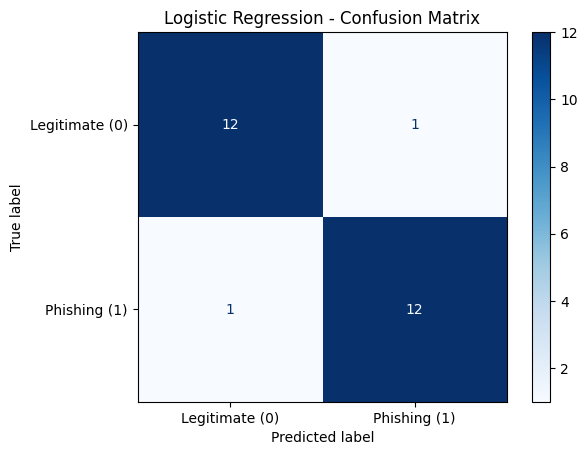


========== SVM ==========
Accuracy : 0.5769
Precision: 1.0000  (Phishing = 1)
Recall   : 0.1538  (Detect Phishing)
F1-Score : 0.2667
AUC      : 0.3905


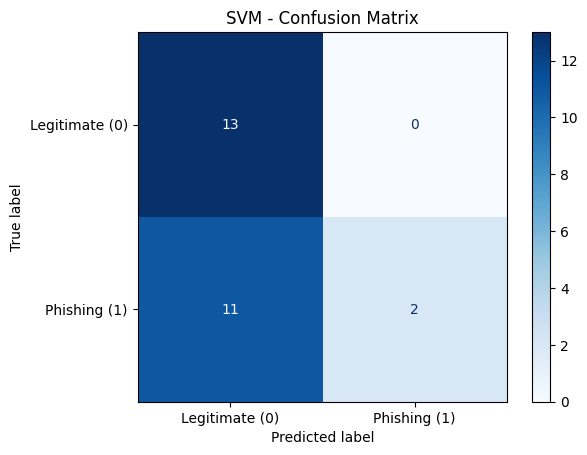


========== RandomForest ==========
Accuracy : 0.9615
Precision: 0.9286  (Phishing = 1)
Recall   : 1.0000  (Detect Phishing)
F1-Score : 0.9630
AUC      : 0.9822


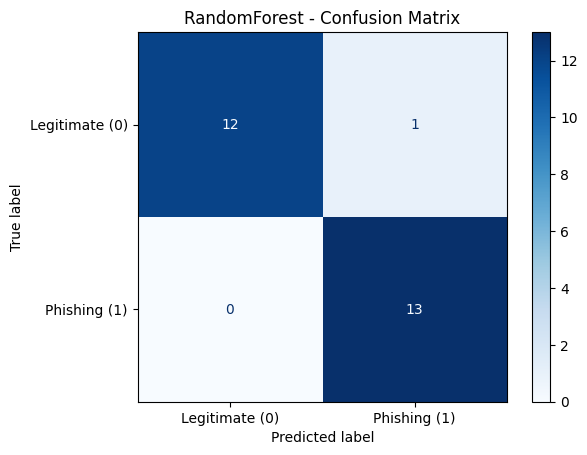


========== XGBoost ==========
Accuracy : 0.9231
Precision: 0.8667  (Phishing = 1)
Recall   : 1.0000  (Detect Phishing)
F1-Score : 0.9286
AUC      : 0.9941


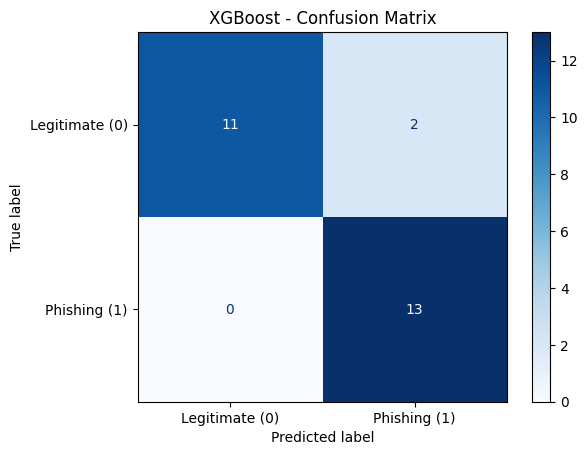


========== AdaBoost ==========
Accuracy : 0.9231
Precision: 0.8667  (Phishing = 1)
Recall   : 1.0000  (Detect Phishing)
F1-Score : 0.9286
AUC      : 0.9645


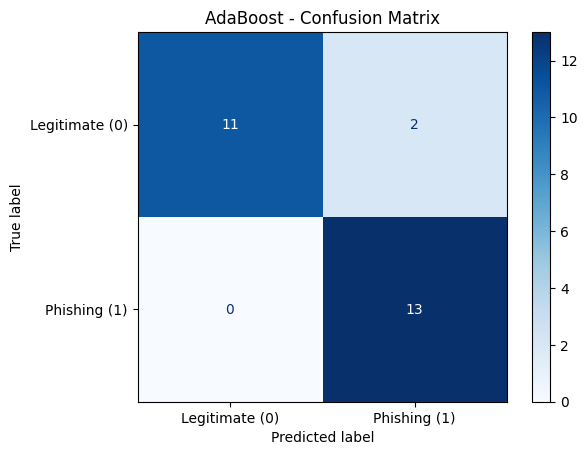


========== CatBoost ==========
Accuracy : 0.9231
Precision: 0.9231  (Phishing = 1)
Recall   : 0.9231  (Detect Phishing)
F1-Score : 0.9231
AUC      : 0.9527


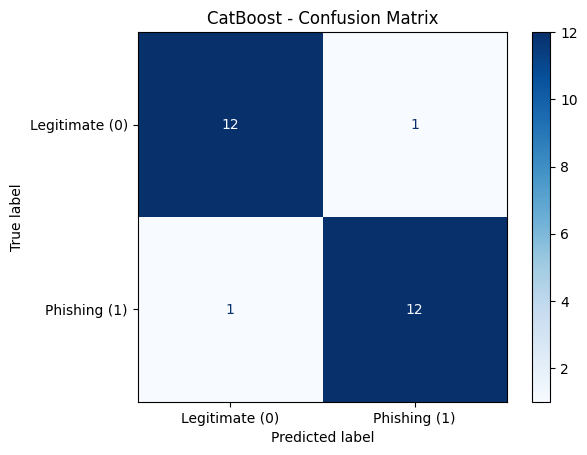


========== LightGBM ==========
Accuracy : 0.9231
Precision: 0.8667  (Phishing = 1)
Recall   : 1.0000  (Detect Phishing)
F1-Score : 0.9286
AUC      : 0.9822


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


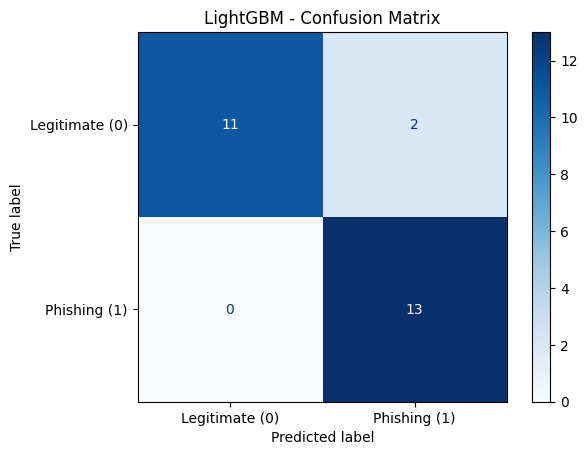


========== EBM ==========
Accuracy : 0.9231
Precision: 0.8667  (Phishing = 1)
Recall   : 1.0000  (Detect Phishing)
F1-Score : 0.9286
AUC      : 0.9704


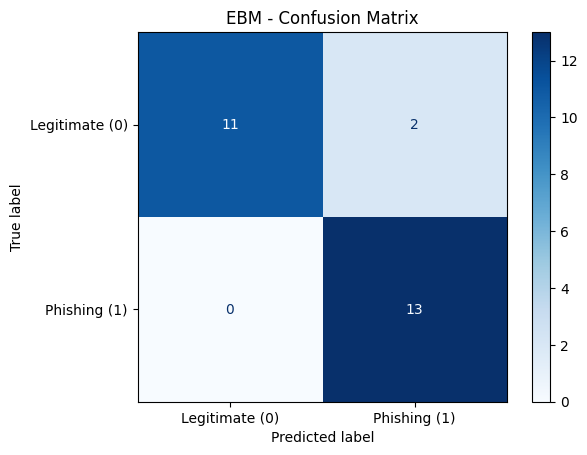


===== Summary of All Model Metrics (Focus: Phishing = 1) =====
                 Model  Accuracy  Precision    Recall        F1       AUC
1  Logistic Regression  0.923077   0.923077  0.923077  0.923077  0.970414
2                  SVM  0.576923   1.000000  0.153846  0.266667  0.390533
3         RandomForest  0.961538   0.928571  1.000000  0.962963  0.982249
4              XGBoost  0.923077   0.866667  1.000000  0.928571  0.994083
5             AdaBoost  0.923077   0.866667  1.000000  0.928571  0.964497
6             CatBoost  0.923077   0.923077  0.923077  0.923077  0.952663
7             LightGBM  0.923077   0.866667  1.000000  0.928571  0.982249
8                  EBM  0.923077   0.866667  1.000000  0.928571  0.970414

===== Plot Top 20 Features for Each Model =====

>>> Logistic Regression


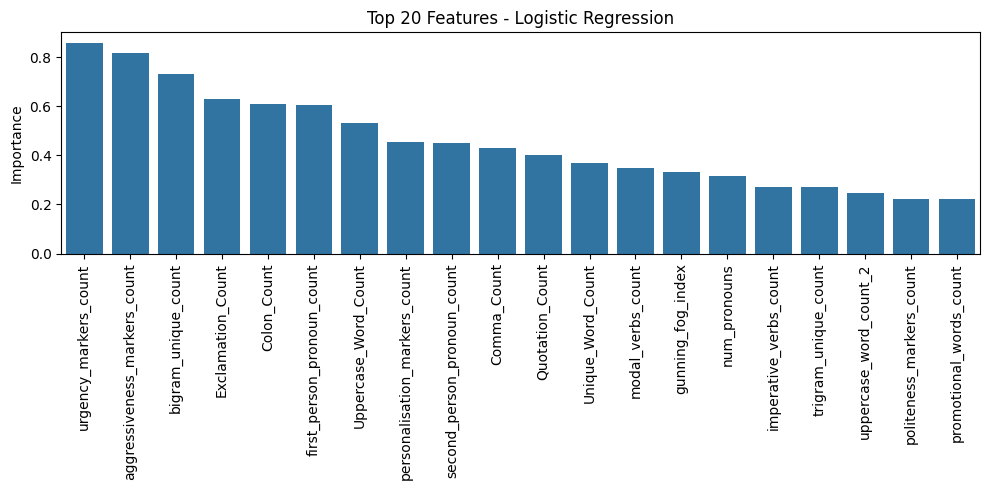


>>> SVM
[SVM] ไม่มี feature importance ที่ใช้งานง่าย (ข้ามการ plot).

>>> RandomForest


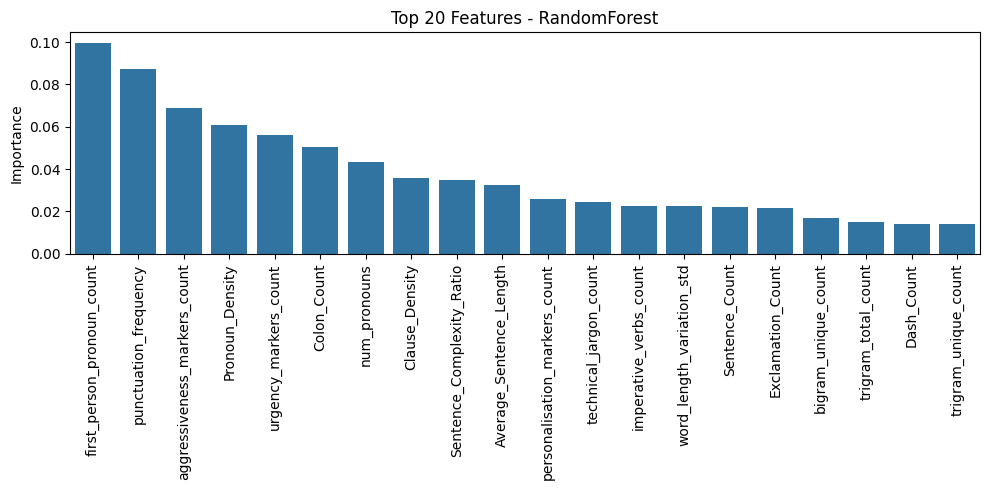


>>> XGBoost


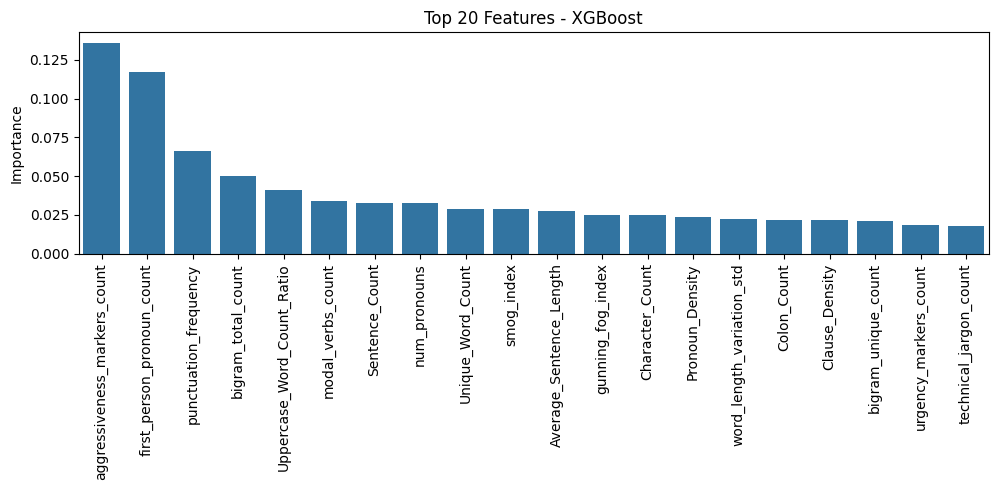


>>> AdaBoost


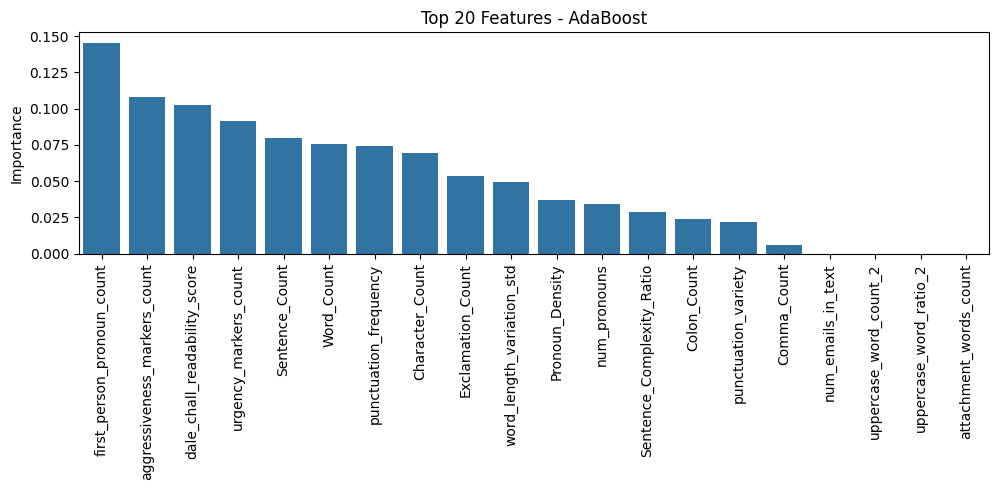


>>> CatBoost


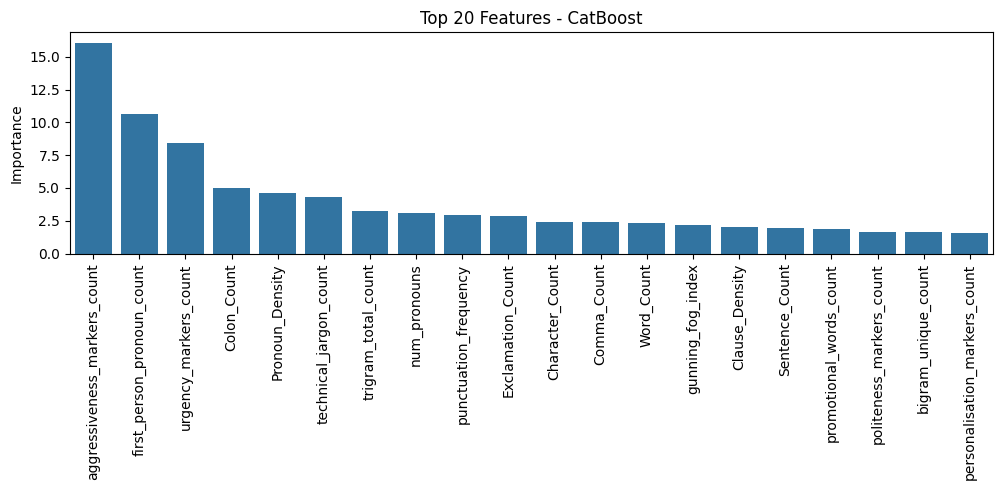


>>> LightGBM


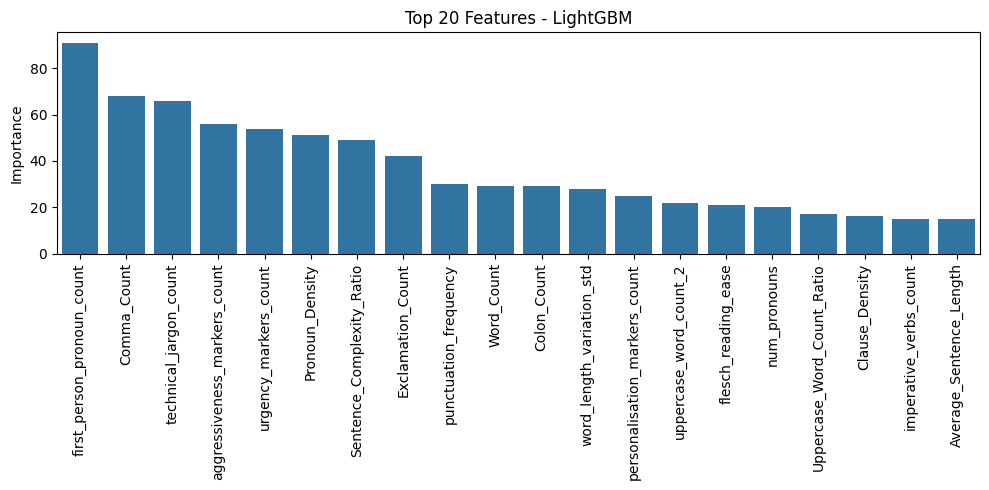


>>> EBM
[EBM] ไม่มี feature importance ที่ใช้งานง่าย (ข้ามการ plot).

✅ Saved:
- model_metrics_summary.xlsx
- email_features_with_all_features.csv


In [49]:
# ==========================================================
# PART 3 : MAIN SCRIPT – RUN PIPELINE
# ==========================================================
if __name__ == "__main__":
    DATA_PATH = "email_features.csv"   # ต้องมี Subject, Body, Label
    USE_EXCEL = False                  # ถ้าใช้ .xlsx ให้เปลี่ยนเป็น True

    # ----- Step 1: Load -----
    if USE_EXCEL:
        df = load_email_excel(DATA_PATH)
    else:
        df = load_email_csv(DATA_PATH)

    # ----- Step 2: Build Features -----
    feature_df = build_feature_dataframe(df)

    # ----- Step 3: Prepare X, y -----
    X, y, feature_cols = prepare_X_y(feature_df, label_col="Label")
    print("X shape:", X.shape)
    print("y shape:", y.shape)

    # ----- Step 4: Train/Test Split -----
    X_train, X_test, y_train, y_test = train_test_split_data(
        X, y, test_size=0.2, random_state=42
    )

    # ----- Step 5: Define & Train Models -----
    base_models = get_models(random_state=42)
    trained_models = train_models(base_models, X_train, y_train)

    # ----- Step 6: Evaluate All Models -----
    df_metrics = evaluate_all_models(trained_models, X_test, y_test)

    # ----- Step 7: Plot Top 20 Features ของแต่ละโมเดล -----
    print("\n===== Plot Top 20 Features for Each Model =====")
    for name, model in trained_models.items():
        print(f"\n>>> {name}")
        plot_top_features(name, model, X_train, top_n=20)

    # ----- Step 8: Save metrics & features -----
    df_metrics.to_excel("model_metrics_summary.xlsx", index=False)
    feature_df.to_csv("email_features_with_all_features.csv",
                      index=False,
                      encoding="utf-8-sig")

    print("\n✅ Saved:")
    print("- model_metrics_summary.xlsx")
    print("- email_features_with_all_features.csv")
